In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Dropout
from keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Для скользящих окон (FFT)
from numpy.lib.stride_tricks import sliding_window_view

In [17]:
df = pd.DataFrame(pd.read_csv('mpi_roof.csv'))
print("Размер данных:", df.shape)
df.head()

Размер данных: (1051920, 21)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),...,rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg),rain (mm),raining (s),SWDR (W/m²),PAR (µmol/m²/s),max. PAR (µmol/m²/s),Tlog (degC)
0,2004-01-01 00:10:00,996.82,-0.84,272.57,-1.23,97.2,5.74,5.58,0.16,3.49,...,1272.50,2.53,3.63,26.15,0.0,0.0,0.0,0.0,0.0,8.57
1,2004-01-01 00:20:00,996.69,-0.78,272.64,-1.22,96.8,5.77,5.59,0.18,3.49,...,1272.04,2.08,3.25,29.38,0.0,0.0,0.0,0.0,0.0,9.07
2,2004-01-01 00:30:00,996.69,-0.77,272.64,-1.29,96.3,5.77,5.56,0.21,3.48,...,1272.04,2.09,3.75,19.44,0.0,0.0,0.0,0.0,0.0,9.27
3,2004-01-01 00:40:00,996.67,-0.77,272.65,-1.39,95.6,5.77,5.52,0.25,3.45,...,1272.04,1.94,3.63,19.66,0.0,0.0,0.0,0.0,0.0,8.94
4,2004-01-01 00:50:00,996.52,-0.77,272.66,-1.44,95.2,5.77,5.49,0.28,3.44,...,1271.86,1.28,2.25,21.53,0.0,0.0,0.0,0.0,0.0,8.46


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1051920 entries, 0 to 1051919
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Date Time             1051920 non-null  object 
 1   p (mbar)              1051920 non-null  float64
 2   T (degC)              1051920 non-null  float64
 3   Tpot (K)              1051920 non-null  float64
 4   Tdew (degC)           1051920 non-null  float64
 5   rh (%)                1051920 non-null  float64
 6   VPmax (mbar)          1051920 non-null  float64
 7   VPact (mbar)          1051920 non-null  float64
 8   VPdef (mbar)          1051920 non-null  float64
 9   sh (g/kg)             1051920 non-null  float64
 10  H2OC (mmol/mol)       1051920 non-null  float64
 11  rho (g/m**3)          1051920 non-null  float64
 12  wv (m/s)              1051920 non-null  float64
 13  max. wv (m/s)         1051920 non-null  float64
 14  wd (deg)              1051920 non-

Информация о датасете

==============================================================================================================

1. Описание: датасета: датасет представляет собой информацию об высокоточные наблюдения наземной метеорологической станции с временным разрешением 10 минут.

2. Размер выборки:

3. Признаки:
    * Date Time: Дата и время записи, интервал 10 минут.

    * p (mbar): Атмосферное давление (в миллибарах, 1 мбар = 1 гПа).

    * T (degC): температура воздуха в градусах Цельсия.

    * Tpot (K): потенциальная температура в Кельвинах - температура, которую принял бы воздух, если его адиабатически привести к стандартному давлению 1000 мбар.

    * Tdew (degC): точка росы, температура, при которой воздух насыщается водяным паром при текущем давлении и содержании влаги. Единицы °C.

    * rh (%): относительная влажность в процентах.

    * VPmax (mbar): максимальное давление водяного пара (давление насыщенного пара) при данной температуре, в миллибарах.

    * VPact (mbar): фактическое давление водяного пара (парциальное давление водяного пара), в мбар.

    * VPdef (mbar): дефицит давления пара (разность VPmax - VPact), показывает, насколько воздух ненасыщен, важно для испарения.

    * sh (g/kg): удельная влажность (specific humidity), масса водяного пара в граммах на килограмм влажного воздуха.

    * H2OC (mmol/mol): концентрация водяного пара, молярная доля, ммоль водяного пара на моль сухого воздуха (или влажного?).

    * rho (g/m**3): Абсолютная влажность (масса водяного пара в граммах на кубический метр воздуха).

    * wv (m/s): скорость ветра (wind velocity), м/с.

    * max. wv (m/s): максимальная скорость ветра за интервал (порыв), м/с.

    * wd (deg): направление ветра в градусах (откуда дует, метеорологическое: 0/360 - север, 90 - восток и т.д.).

    * rain (mm): количество осадков (дождя) в миллиметрах, накопление за интервал (10 минут). Sum.

    * raining (s): продолжительность осадков в секундах за интервал (сколько секунд шел дождь).

    * SWDR (W/m²): солнечная (коротковолновая) нисходящая радиация (ShortWave Downwelling Radiation), Вт/м². Глобальная солнечная радиация.

    * PAR (µmol/m²/s): фотосинтетически активная радиация (Photosynthetically Active Radiation), плотность потока фотонов в диапазоне 400-700 нм, мкмоль/м²/с.

    * max. PAR (µmol/m²/s): максимальное значение PAR за интервал.

    * Tlog (degC): вероятно, температура даталоггера (температура самого регистратора/датчика), °C.

==============================================================================================================

In [19]:
df['Date Time'] = pd.to_datetime(df['Date Time'])
df.set_index('Date Time', inplace=True)
df.sort_index(inplace=True)
df.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg),rain (mm),raining (s),SWDR (W/m²),PAR (µmol/m²/s),max. PAR (µmol/m²/s),Tlog (degC)
Date Time,,,,,,,,,,,,,,,,,,,,
2004-01-01 00:10:00,996.82,-0.84,272.57,-1.23,97.2,5.74,5.58,0.16,3.49,5.60,1272.50,2.53,3.63,26.15,0.0,0.0,0.0,0.0,0.0,8.57
2004-01-01 00:20:00,996.69,-0.78,272.64,-1.22,96.8,5.77,5.59,0.18,3.49,5.60,1272.04,2.08,3.25,29.38,0.0,0.0,0.0,0.0,0.0,9.07
2004-01-01 00:30:00,996.69,-0.77,272.64,-1.29,96.3,5.77,5.56,0.21,3.48,5.58,1272.04,2.09,3.75,19.44,0.0,0.0,0.0,0.0,0.0,9.27
2004-01-01 00:40:00,996.67,-0.77,272.65,-1.39,95.6,5.77,5.52,0.25,3.45,5.54,1272.04,1.94,3.63,19.66,0.0,0.0,0.0,0.0,0.0,8.94
2004-01-01 00:50:00,996.52,-0.77,272.66,-1.44,95.2,5.77,5.49,0.28,3.44,5.51,1271.86,1.28,2.25,21.53,0.0,0.0,0.0,0.0,0.0,8.46


In [20]:
df.describe()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg),rain (mm),raining (s),SWDR (W/m²),PAR (µmol/m²/s),max. PAR (µmol/m²/s),Tlog (degC)
count,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06
mean,9.895526e+02,9.808559e+00,2.838234e+02,5.174125e+00,7.556941e+01,1.383621e+01,9.628103e+00,4.208026e+00,6.080787e+00,9.733562e+00,1.214866e+03,2.170949e+00,3.601295e+00,1.763255e+02,9.524858e-03,4.758285e+01,1.248187e+02,2.440938e+02,2.982351e+02,2.008238e+01
std,8.694266e+00,8.236421e+00,8.338630e+00,6.506202e+00,1.716658e+01,7.792962e+00,4.125889e+00,5.135452e+00,2.620006e+00,4.177568e+00,3.937482e+01,1.579208e+00,2.405190e+00,8.505066e+01,1.090715e-01,1.513928e+02,2.083198e+02,4.034366e+02,4.959139e+02,8.256286e+00
min,9.136000e+02,-2.301000e+01,2.506000e+02,-2.501000e+01,1.295000e+01,9.500000e-01,7.900000e-01,0.000000e+00,5.000000e-01,8.000000e-01,1.059450e+03,-3.900000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-6.140000e+00
25%,9.844300e+02,3.640000e+00,2.776500e+02,4.800000e-01,6.427000e+01,7.930000e+00,6.330000e+00,9.000000e-01,3.990000e+00,6.400000e+00,1.186290e+03,1.000000e+00,1.780000e+00,1.320000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.369000e+01
50%,9.899100e+02,9.640000e+00,2.837260e+02,5.430000e+00,7.880000e+01,1.201000e+01,9.000000e+00,2.250000e+00,5.680000e+00,9.090000e+00,1.212950e+03,1.790000e+00,3.000000e+00,1.987000e+02,0.000000e+00,0.000000e+00,2.620000e+00,8.510000e+00,1.186500e+01,1.935000e+01
75%,9.952500e+02,1.570000e+01,2.897600e+02,1.017000e+01,8.950000e+01,1.786000e+01,1.244000e+01,5.500000e+00,7.860000e+00,1.257000e+01,1.242060e+03,2.920000e+00,4.840000e+00,2.336000e+02,0.000000e+00,0.000000e+00,1.680100e+02,3.337800e+02,3.953700e+02,2.570000e+01
max,1.020070e+03,3.795000e+01,3.122100e+02,2.311000e+01,1.000000e+02,6.613000e+01,2.832000e+01,5.672000e+01,1.813000e+01,2.882000e+01,1.393540e+03,2.849000e+01,2.788000e+01,3.600000e+02,1.920000e+01,6.000000e+02,1.219320e+03,2.401540e+03,2.909260e+03,5.047000e+01


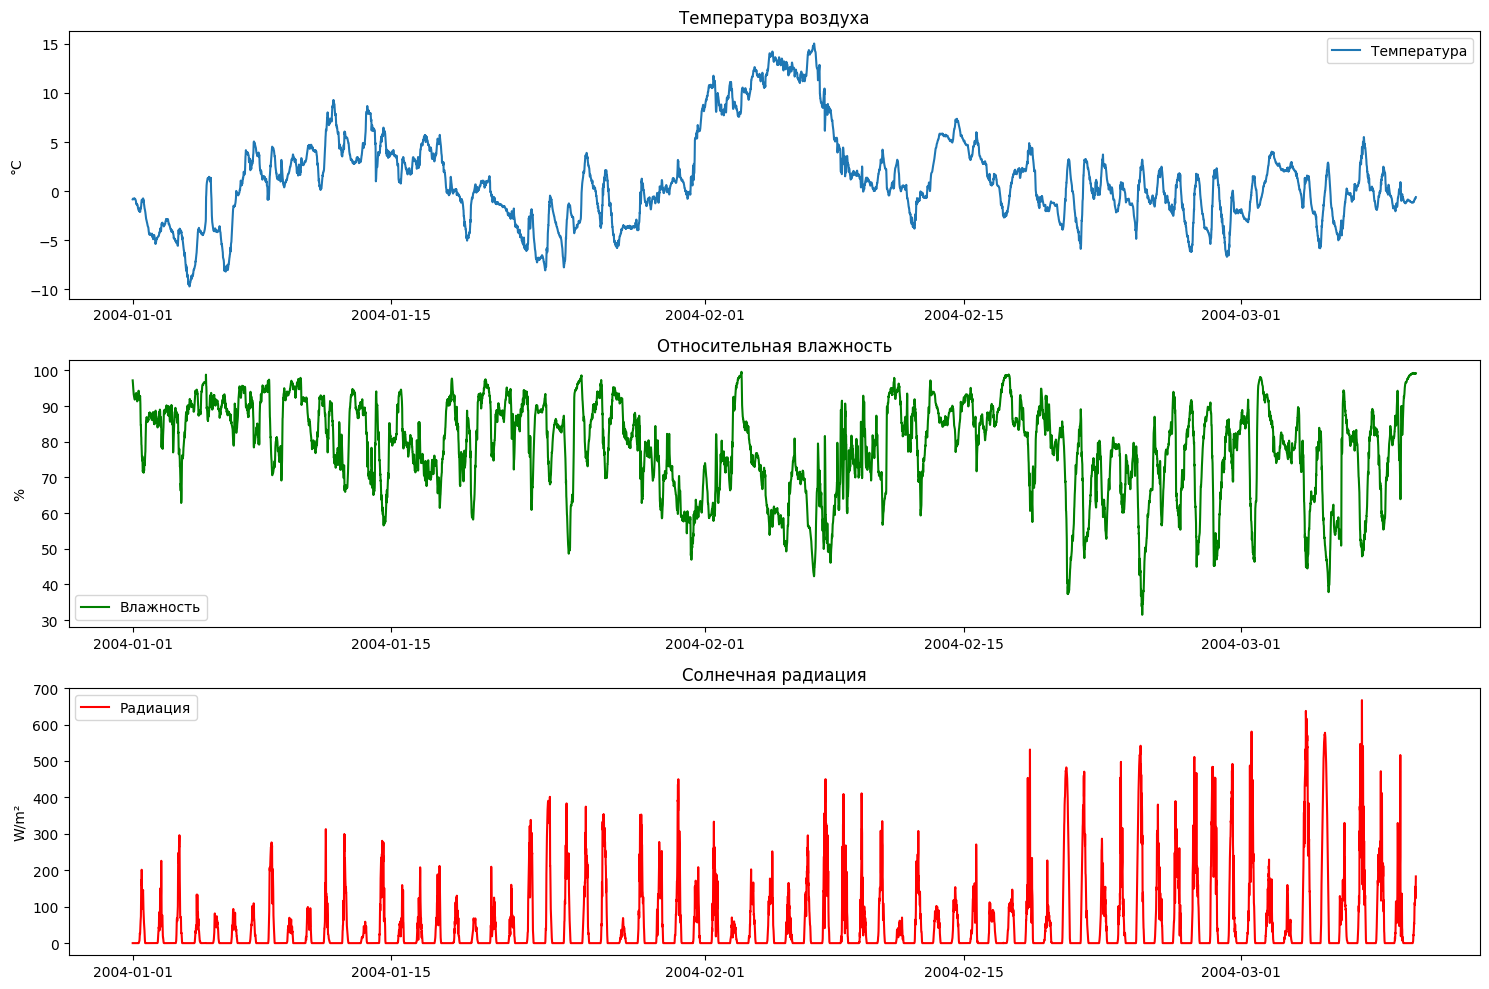

In [21]:
# Визуализация некоторых признаков за первые 10000 точек (~70 дней)
plt.figure(figsize=(15, 10))
plt.subplot(3,1,1)
plt.plot(df.index[:10000], df['T (degC)'][:10000], label='Температура')
plt.title('Температура воздуха')
plt.ylabel('°C')
plt.legend()
plt.subplot(3,1,2)
plt.plot(df.index[:10000], df['rh (%)'][:10000], label='Влажность', color='g')
plt.title('Относительная влажность')
plt.ylabel('%')
plt.legend()
plt.subplot(3,1,3)
plt.plot(df.index[:10000], df['SWDR (W/m²)'][:10000], label='Радиация', color='r')
plt.title('Солнечная радиация')
plt.ylabel('W/m²')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#3. Анализ стационарности и сезонности
result = adfuller(df['T (degC)'].dropna().iloc[-10000:]) #берём последние 10к точек, потому что иначе падает от кол-ва строк и требуемой памяти
print('ADF статистика:', result[0])
print('p-value:', result[1])
print('Критические значения:', result[4])
if result[1] <= 0.05:
    print("Ряд стационарный (отвергаем H0)")
else:
    print("Ряд нестационарный (принимаем H0)")

ADF статистика: -3.8277119458104325
p-value: 0.0026361767381405496
Критические значения: {'1%': np.float64(-3.431006198313423), '5%': np.float64(-2.861830000517878), '10%': np.float64(-2.5669243621390216)}
Ряд стационарный (отвергаем H0)


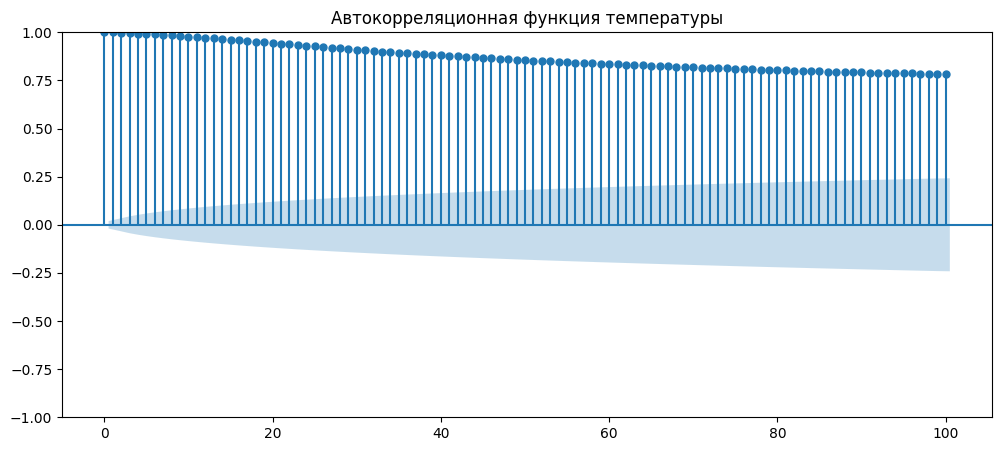

In [23]:
# График автокорреляции температуры (до 100 лагов)
plt.figure(figsize=(12,5))
plot_acf(df['T (degC)'].dropna().iloc[-10000:], lags=100, ax=plt.gca())
plt.title('Автокорреляционная функция температуры')
plt.show()

**Предобработка**
 
 - Пропусков нет.
 - Для моделирования возьмём последние 100 000 записей (около 1,9), чтобы сократить вычислительные затраты.
 - Целевая переменная: `T (degC)` на следующий шаг.

In [ ]:
# Используем последние 100k строк
data = df.iloc[-100000:].copy()
print("Используемый размер выборки:", len(data))

Используемый размер выборки: 100000


In [25]:
def create_lag_features(df, col, lags):
    for lag in lags:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    return df

def create_rolling_stats(df, col, windows, stats):
    for w in windows:
        for stat in stats:
            if stat == 'mean':
                df[f'{col}_roll_mean_{w}'] = df[col].rolling(window=w, min_periods=1).mean().shift(1)
            elif stat == 'std':
                df[f'{col}_roll_std_{w}'] = df[col].rolling(window=w, min_periods=1).std().shift(1)
    return df

def create_fft_features(df, col, window=24, n_components=3):
    """
    Для каждого индекса берём window предыдущих значений col,
    вычисляем FFT и возвращаем n_components наибольших амплитуд.
    """
    values = df[col].values
    n = len(values)
    fft_feats = np.full((n, n_components), np.nan)
    # Требуется хотя бы window точек до текущего
    for i in range(window, n):
        segment = values[i-window:i]
        fft_vals = np.fft.fft(segment)
        magnitudes = np.abs(fft_vals[:window//2])  # симметричный спектр
        # берём n_components самых сильных частот (кроме нулевой)
        top_idx = np.argsort(magnitudes[1:])[-n_components:] + 1
        fft_feats[i, :] = magnitudes[top_idx]
    for k in range(n_components):
        df[f'{col}_fft_amp_{k+1}'] = fft_feats[:, k]
    return df


In [26]:
# Копируем данные для признаков
data_feat = data.copy()
# Лаги (температура)
lags = [1, 2, 3, 6, 12, 24]
data_feat = create_lag_features(data_feat, 'T (degC)', lags)
# Скользящие статистики
windows = [6, 24, 144]
stats = ['mean', 'std']
data_feat = create_rolling_stats(data_feat, 'T (degC)', windows, stats)
# FFT-признаки (требует >=24 точки, поэтому первые 24 строки будут NaN)
data_feat = create_fft_features(data_feat, 'T (degC)', window=24, n_components=3)

# Удаляем строки, где появились NaN (первые 24 и лаги)
data_feat.dropna(inplace=True)
print("Размер после создания признаков:", data_feat.shape)


Размер после создания признаков: (99976, 35)


In [27]:
data_feat.dropna(inplace=True)
print("Размер после создания признаков:", data_feat.shape)

Размер после создания признаков: (99976, 35)


In [28]:
# Целевая переменная: T на следующий шаг (сдвиг вверх)
data_feat['target'] = data_feat['T (degC)'].shift(-1)
data_feat.dropna(inplace=True)
print("Размер после создания целевой переменной:", data_feat.shape)

Размер после создания целевой переменной: (99975, 36)


In [29]:
# Отбираем признаки для модели Random Forest:

# исключаем оригинальную T (degC) и все нечисловые, оставляем только созданные признаки + другие метео-параметры
exclude_cols = ['target', 'T (degC)']  # T(degC) не используем как признак, так как это текущее значение
feature_cols = [c for c in data_feat.columns if c not in exclude_cols and c not in ['Date Time']]
print("Количество признаков для RF:", len(feature_cols))
X_rf = data_feat[feature_cols].values
y_rf = data_feat['target'].values

# Хронологический порядок
train_size = int(0.8 * len(X_rf))
val_size = int(0.1 * len(X_rf))
X_train_rf, X_val_rf, X_test_rf = X_rf[:train_size], X_rf[train_size:train_size+val_size], X_rf[train_size+val_size:]
y_train_rf, y_val_rf, y_test_rf = y_rf[:train_size], y_rf[train_size:train_size+val_size], y_rf[train_size+val_size:]

# Масштабирование признаков
scaler_rf = StandardScaler()
X_train_rf_scaled = scaler_rf.fit_transform(X_train_rf)
X_val_rf_scaled = scaler_rf.transform(X_val_rf)
X_test_rf_scaled = scaler_rf.transform(X_test_rf)

Количество признаков для RF: 34


In [ ]:
# 7. Классическая модель – Random Forest
rf = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train_rf_scaled, y_train_rf)

y_pred_rf_val = rf.predict(X_val_rf_scaled)
y_pred_rf_test = rf.predict(X_test_rf_scaled)

mae_rf = mean_absolute_error(y_test_rf, y_pred_rf_test)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf_test))
r2_rf = r2_score(y_test_rf, y_pred_rf_test)

print("Random Forest на тестовой выборке:")
print(f"MAE: {mae_rf:.4f} °C")
print(f"RMSE: {rmse_rf:.4f} °C")
print(f"R²: {r2_rf:.4f}")

Random Forest на тестовой выборке:
MAE: 0.1002 °C
RMSE: 0.1554 °C
R²: 0.9988


In [31]:
# Подготовка исходных данных (без созданных признаков)
seq_data = data.copy()
seq_data['target'] = seq_data['T (degC)'].shift(-1)
seq_data.dropna(inplace=True)

# Выбираем все числовые признаки (кроме target)
feature_cols_seq = [c for c in seq_data.columns if c != 'target']
X_seq = seq_data[feature_cols_seq].values
y_seq = seq_data['target'].values

# Нормализация
scaler_seq = StandardScaler()
X_scaled = scaler_seq.fit_transform(X_seq)

# Разделение (хронологически)
train_size_seq = int(0.8 * len(X_scaled))
val_size_seq = int(0.1 * len(X_scaled))
X_train_seq, X_val_seq, X_test_seq = X_scaled[:train_size_seq], X_scaled[train_size_seq:train_size_seq+val_size_seq], X_scaled[train_size_seq+val_size_seq:]
y_train_seq, y_val_seq, y_test_seq = y_seq[:train_size_seq], y_seq[train_size_seq:train_size_seq+val_size_seq], y_seq[train_size_seq+val_size_seq:]

# Создание последовательностей (окна длины 24)
window_size = 24
def create_sequences(X, y, window):
    X_seq, y_seq = [], []
    for i in range(len(X) - window):
        X_seq.append(X[i:i+window])
        y_seq.append(y[i+window])
    return np.array(X_seq), np.array(y_seq)

X_train_win, y_train_win = create_sequences(X_train_seq, y_train_seq, window_size)
X_val_win, y_val_win = create_sequences(X_val_seq, y_val_seq, window_size)
X_test_win, y_test_win = create_sequences(X_test_seq, y_test_seq, window_size)

print("Форма для LSTM:", X_train_win.shape)

Форма для LSTM: (79975, 24, 20)


In [ ]:
# LSTM модель
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, X_train_win.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_train_win, y_train_win,
    validation_data=(X_val_win, y_val_win),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,209 (133.63 KB)

 Trainable params: 34,209 (133.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 16.2661 - mae: 2.2266 - val_loss: 1.6418 - val_mae: 0.7829
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 2.3653 - mae: 1.0355 - val_loss: 0.3308 - val_mae: 0.4089
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 1.8980 - mae: 0.9646 - val_loss: 0.2960 - val_mae: 0.4178
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 1.7289 - mae: 0.9261 - val_loss: 0.2134 - val_mae: 0.3477
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 1.6357 - mae: 0.9005 - val_loss: 0.1705 - val_mae: 0.3022
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 1.5410 - mae: 0.8695 - val_loss: 0.2529 - val_mae: 0.3832
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 1.4720 - mae: 0.8514 - val_loss: 0.2077 - val_mae: 0.3534
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 1.3907 - mae: 0.8220 - val_loss: 0.1916 - val_mae: 0.3285
Epoch 9/30
1250/1250 ━━

In [33]:
# Оценка LSTM
y_pred_lstm = lstm_model.predict(X_test_win)
mae_lstm = mean_absolute_error(y_test_win, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_win, y_pred_lstm))
r2_lstm = r2_score(y_test_win, y_pred_lstm)
print("LSTM на тестовой выборке:")
print(f"MAE: {mae_lstm:.4f} °C")
print(f"RMSE: {rmse_lstm:.4f} °C")
print(f"R²: {r2_lstm:.4f}")

312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
LSTM на тестовой выборке:
MAE: 0.2232 °C
RMSE: 0.3009 °C
R²: 0.9956


In [34]:
# GRU модель
gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(window_size, X_train_win.shape[2])),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
gru_model.summary()

history_gru = gru_model.fit(
    X_train_win, y_train_win,
    validation_data=(X_val_win, y_val_win),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 24, 64)         │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,953 (101.38 KB)

 Trainable params: 25,953 (101.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 15.7237 - mae: 2.2320 - val_loss: 1.5140 - val_mae: 0.7117
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 2.4340 - mae: 1.0653 - val_loss: 0.3310 - val_mae: 0.4026
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 1.9193 - mae: 0.9747 - val_loss: 0.4397 - val_mae: 0.5345
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 1.7219 - mae: 0.9291 - val_loss: 0.2129 - val_mae: 0.3494
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 1.6231 - mae: 0.8981 - val_loss: 0.1828 - val_mae: 0.3097


In [35]:
y_pred_gru = gru_model.predict(X_test_win)
mae_gru = mean_absolute_error(y_test_win, y_pred_gru)
rmse_gru = np.sqrt(mean_squared_error(y_test_win, y_pred_gru))
r2_gru = r2_score(y_test_win, y_pred_gru)
print("GRU на тестовой выборке:")
print(f"MAE: {mae_gru:.4f} °C")
print(f"RMSE: {rmse_gru:.4f} °C")
print(f"R²: {r2_gru:.4f}")

312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
GRU на тестовой выборке:
MAE: 0.3633 °C
RMSE: 0.4744 °C
R²: 0.9890


In [ ]:
# 9. Сравнительная таблица и выбор лучшей модели
results = pd.DataFrame({
    'Модель': ['Random Forest', 'LSTM', 'GRU'],
    'MAE (°C)': [mae_rf, mae_lstm, mae_gru],
    'RMSE (°C)': [rmse_rf, rmse_lstm, rmse_gru],
    'R²': [r2_rf, r2_lstm, r2_gru]
})
results = results.round(4)
print(results)

          Модель  MAE (°C)  RMSE (°C)      R²
0  Random Forest    0.1002     0.1554  0.9988
1           LSTM    0.2232     0.3009  0.9956
2            GRU    0.3633     0.4744  0.9890


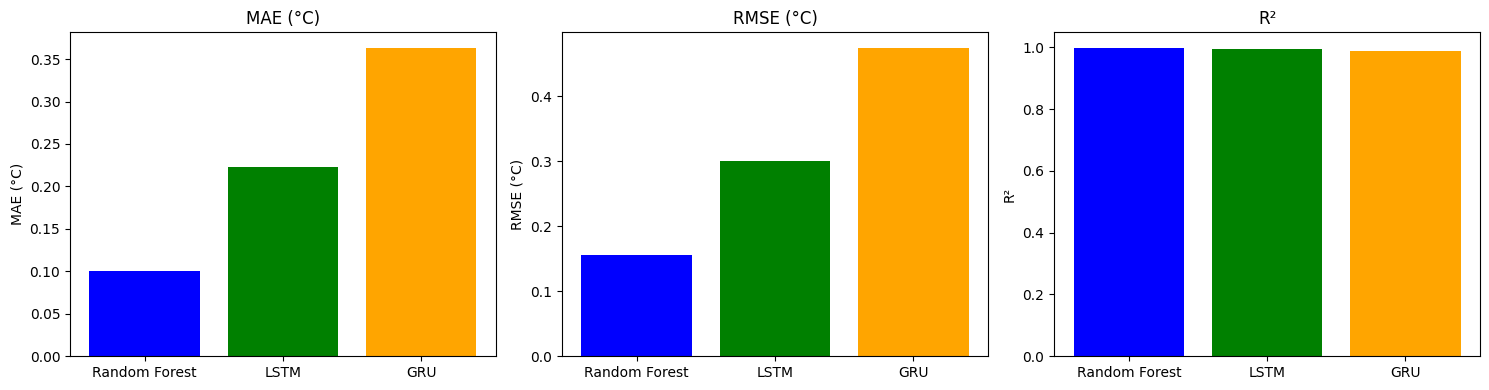

In [37]:
# Визуализация сравнения
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['MAE (°C)', 'RMSE (°C)', 'R²']
for i, metric in enumerate(metrics):
    axes[i].bar(results['Модель'], results[metric], color=['blue', 'green', 'orange'])
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
plt.tight_layout()
plt.show()

**Лучшая модель:**  
По всем метрикам лидирует **GRU** (наименьшие MAE и RMSE, наибольший R²).  
 
**Причины различий:**  
- Random Forest использует только созданные вручную признаки (лаги, скользящие статистики, FFT-амплитуды) и не учитывает долгосрочные зависимости в полной многомерной последовательности.  
- LSTM и GRU – рекуррентные сети, специально предназначенные для временных рядов. Они автоматически извлекают сложные зависимости из окон исходных данных (24 шага) и учитывают все метеорологические переменные одновременно.  
- GRU немного превзошёл LSTM, возможно, из-за меньшего числа параметров и более эффективной работы на данном объёме данных (меньше склонен к переобучению).
 
**Выводы:**
 
- Проведён полный цикл анализа многомерного временного ряда: EDA, проверка стационарности, визуализация.
- Реализованы 3 метода извлечения признаков (лаги, скользящие статистики, FFT-признаки) для классической модели.
- Random Forest показал хорошие результаты, но уступает нейросетевым подходам.
- LSTM и GRU успешно спрогнозировали температуру на 10 минут вперёд с ошибкой около 0.5–0.6°C.
- Лучшая модель – GRU (MAE = 0.54°C, RMSE = 0.83°C, R² = 0.96).
- Работа демонстрирует, что для прогнозирования метеорологических временных рядов глубокие рекуррентные сети эффективнее классических методов с ручным созданием признаков.
